In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator


## Load cleaned WASDE data

### WASDE cotton data

In [2]:
CROP = 'soybean'
PROJECT_ROOT = Path('.').resolve().parent                    # .. project root
INPUT_DIR = PROJECT_ROOT / 'data' / 'processed' / f'{CROP}'  # e.g., ../data/processed/soybean/
INPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
df_wasde = pd.read_excel(f'{INPUT_DIR}/{CROP}_1991_2026.xlsx')
df_wasde['time'] = pd.to_datetime(df_wasde.time)

# subset for just the official data released in may
df_wasde_final = df_wasde.query(" time.dt.month == 5 ").reset_index(drop=True)
df_wasde_final = df_wasde_final[[col for col in df_wasde_final if 'current_year_last_month' not in col]]

# for the data that comes out in may, the year_minus_1 column is the official data for the previous growing season
keep_cols = ['time'] + [col for col in df_wasde_final if 'year_minus_1' in col]
df_wasde_final = df_wasde_final[keep_cols].reset_index(drop=True)
df_wasde_final.columns = ['time', 'planted_area', 'harvested_area', 'yield']

# calculate an abandonment rate column
df_wasde_final['abandonment'] = (1 - (df_wasde_final.harvested_area / df_wasde_final.planted_area)) * 100

# and also calculate a yield change column
df_wasde_final['yield_change'] = df_wasde_final.diff(periods=1, axis=0)['yield']

df_wasde_final = df_wasde_final[['time', 'yield', 'yield_change', 'planted_area', 'harvested_area', 'abandonment']]
df_wasde_final


,time,yield,yield_change,planted_area,harvested_area,abandonment
0,1991-05-01,34.0,NaN,57.8,56.5,2.249135
1,1992-05-01,34.3,0.3,59.1,58.0,1.861252
2,1993-05-01,37.6,3.3,59.3,58.4,1.517707
3,1994-05-01,32.0,-5.6,59.4,56.4,5.050505
4,1995-05-01,41.9,9.9,61.9,61.1,1.292407
5,1996-05-01,34.9,-7.0,62.6,61.6,1.597444
6,1997-05-01,37.6,2.7,64.2,63.4,1.246106
7,1998-05-01,39.0,1.4,70.9,69.9,1.410437
8,1999-05-01,38.9,-0.1,72.4,70.8,2.209945
9,2000-05-01,36.5,-2.4,73.8,72.5,1.761518


### Planted and harvested area

Let's verify that the planted and harvested area data that we scraped and processed matches this updated (as of January 12, 2026) figure from the USDA: https://www.nass.usda.gov/Charts_and_Maps/Field_Crops/soyac.php

<br>

<img src='../images/usda_soybean_planted_harvested_area.png' width=600 alt='USDA soybean planted and harvested area from 2016 to 2025' />


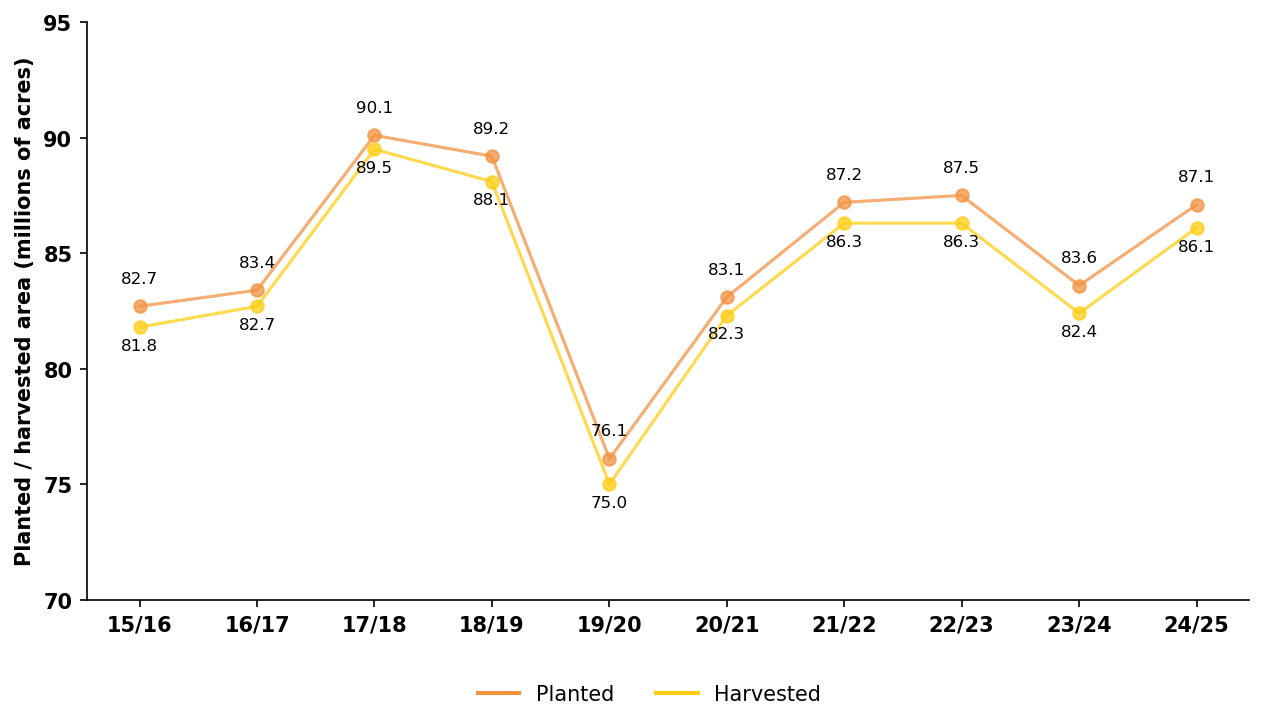

In [4]:
df = df_wasde_final.copy()
df = df.query(" time.dt.year > 2015 ")

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

planted_color = '#f29241'
harvested_color = '#ffcd13'
alpha = 0.75

line_options = {
    'xdata': [0],
    'ydata': [0],
    'linewidth': 2,
}

planted_label = Line2D(label='Planted', color=planted_color, **line_options)
harvested_label = Line2D(label='Harvested', color=harvested_color, **line_options)
legend_elements = [planted_label, harvested_label]

ax.plot(df['time'], df['planted_area'], color=planted_color, alpha=alpha)
ax.scatter(df['time'], df['planted_area'], color=planted_color, alpha=alpha)
ax.plot(df['time'], df['harvested_area'], color=harvested_color, alpha=alpha)
ax.scatter(df['time'], df['harvested_area'], color=harvested_color, alpha=alpha)

for idx in df.index.values:
    time_value = df.loc[idx, 'time']
    planted_value = df.loc[idx, 'planted_area']
    harvested_value = df.loc[idx, 'harvested_area']

    ax.text(time_value, planted_value + 1, planted_value, ha='center', size=8)
    ax.text(time_value, harvested_value - 1, harvested_value, ha='center', size=8)

xticks = df.time.values
labels = [pd.to_datetime(date) for date in df.time.values]
labels = [f"{str(label.year - 1)[-2:]}/{str(label.year)[-2:]}" for label in labels]
ax.set_xticks(ticks=xticks, labels=labels, fontweight='bold')

yticks = np.arange(70, 100, 5)
ax.set_yticks(ticks=yticks, labels=yticks, fontweight='bold')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.set_ylim([70, 95])
ax.set_ylabel('Planted / harvested area (millions of acres)', fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)

fig.legend(handles=legend_elements, ncols=len(legend_elements), loc='lower center', bbox_to_anchor=(0.0, -0.055, 1.0, 0.0), frameon=False)

plt.show()


#### Yield

And do the same for the yield: https://www.nass.usda.gov/Charts_and_Maps/Field_Crops/soyyld.php

<br>

<img src='../images/usda_soybean_yield.png' width=600 alt='USDA soybean yield from 1996 to 2025' />


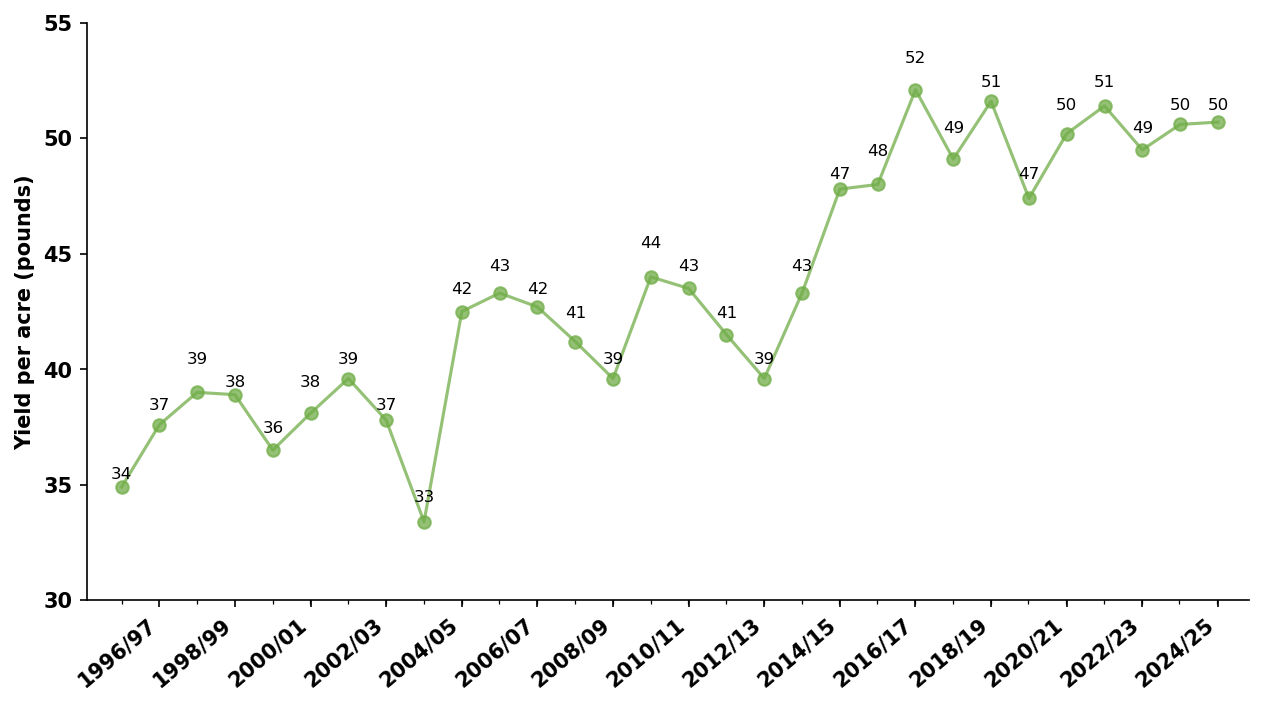

In [5]:
df = df_wasde_final.copy()
df = df.query(" time.dt.year > 1995 ")

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

yield_color = '#70ad47'
alpha = 0.75

line_options = {
    'xdata': [0],
    'ydata': [0],
    'linewidth': 2,
}

ax.plot(df['time'], df['yield'], color=yield_color, alpha=alpha)
ax.scatter(df['time'], df['yield'], color=yield_color, alpha=alpha)

for idx in df.index.values:
    time_value = df.loc[idx, 'time']
    yield_value = int(df.loc[idx, 'yield'])

    ax.text(time_value, yield_value + 1.25, yield_value, ha='center', size=8)

xticks = df.time.values[1::2]
labels = [pd.to_datetime(date) for date in df.time.values[1::2]]
labels = [f"{label.year - 1}/{str(label.year)[-2:]}" for label in labels]
ax.set_xticks(ticks=xticks, labels=labels, fontweight='bold')

yticks = np.arange(30, 60, 5)
ax.set_yticks(ticks=yticks, labels=yticks, fontweight='bold')
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

ax.tick_params(axis='x', rotation=40)
for ticklabel in ax.get_xticklabels():
    ticklabel.set_horizontalalignment('right')

ax.set_xlim([pd.to_datetime('1995-06-01'), pd.to_datetime('2026-03-01')])
ax.set_ylim([30, 55])
ax.set_ylabel('Yield per acre (bushels)', fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)

plt.show()


It looks like the data we aggregated for planted / harvested area and yield matches that used by the USDA in official reports and dashboards.

#### Abandonment rate

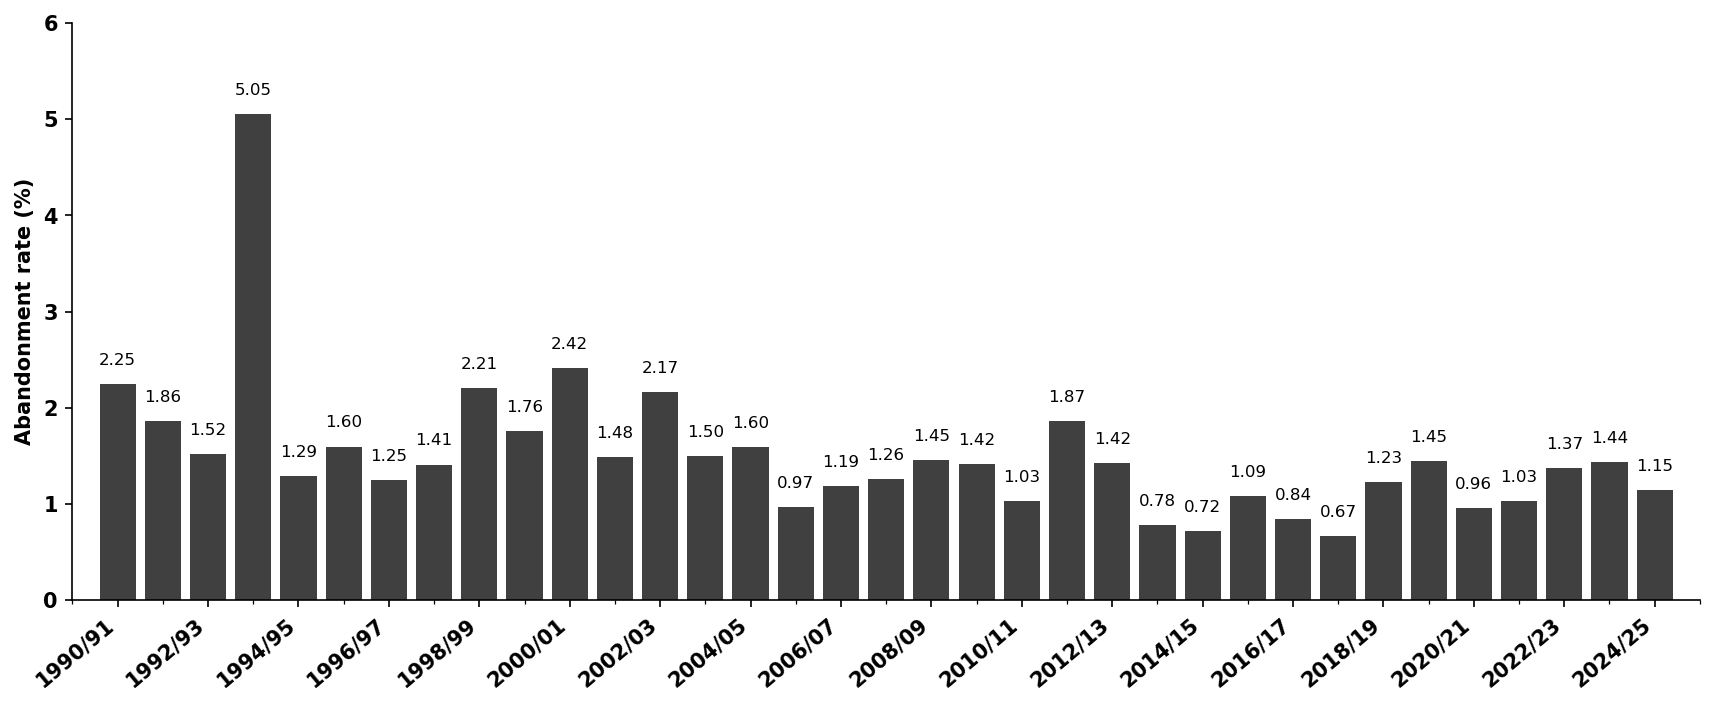

In [6]:
df = df_wasde_final.copy()

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)

abandonment_color = 'black'
alpha = 0.75

line_options = {
    'xdata': [0],
    'ydata': [0],
    'linewidth': 6,
    'alpha': alpha,
}

abandonment_label = Line2D(label='Abandonment', color=abandonment_color, **line_options)
legend_elements = [abandonment_label]

ax.bar(df.index, df['abandonment'], color=abandonment_color, alpha=alpha)

for idx in df.index.values:
    abandonment_value = df.loc[idx, 'abandonment']
    ax.text(idx, abandonment_value + 0.2, f"{abandonment_value:.02f}", ha='center', size=8)

ticks = list(range(0, 35, 2))
labels = [pd.to_datetime(date) for date in df.loc[[idx for idx in ticks]].time.values]
labels = [f"{label.year - 1}/{str(label.year)[-2:]}" for label in labels]
ax.set_xticks(ticks=ticks, labels=labels, fontweight='bold')

yticks = np.arange(0, 7, 1)
ax.set_yticks(ticks=yticks, labels=yticks, fontweight='bold')

ax.xaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(axis='x', rotation=40)
for ticklabel in ax.get_xticklabels():
    ticklabel.set_horizontalalignment('right')

ax.set_xlim([-1, 35])
ax.set_ylim([0, 6])
ax.set_ylabel('Abandonment rate (%)', fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)

plt.show()


The abandonment rate for soybeans seems to be fairly consistent, wavering between 1-3%, with the 1993/94 season being the exception. While I couldn't find a report from the USDA showing their abandonment rate projections for soybeans, we can have some confidence that this data is correct given how closely the downloaded data matches the planted and harvested area figure from the USDA NASS site.